# Series de Tiempo: ITS, Discontinuidad (RDiT) y GEE
## ¿Hay un "escalón" cuando empiezan las clases?

Tres miradas de series de tiempo sobre la serie diaria (promedio de estaciones):
- ITS: tendencia + estacionalidad de Fourier + errores ARMA; ¿el estado "clase" sube el nivel?
- Saltos por corte: regresión segmentada ±60 días alrededor de cada inicio (HAC).
- RDiT: lupa de ±28/±42/±56 días con "donut" de ±2 días alrededor de cada inicio, y
  cortes de referencia a mitad de vacaciones (falsación). Los cortes salen del calendario oficial (notebook 01).
- GEE AR(1) por estación: método de reserva (solo 6 clusters: interpretar con cautela).

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Secondary exploratory analyses (ITS, RDiT, GEE): kept for completeness and reproducibility. They are not reported in the article and do not define its conclusions. / Análisis secundarios exploratorios (ITS, RDiT, GEE): se conservan por completitud y reproducibilidad. No aparecen en el artículo ni definen sus conclusiones. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.genmod.cov_struct import Autoregressive
from statsmodels.genmod.generalized_estimating_equations import GEE
import json
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']
colores_contaminantes = {'CO': '#3498db', 'NO2': '#e74c3c', 'O3': '#2ecc71',
                         'PM10': '#f39c12', 'PM2.5': '#9b59b6'}

output_dir = Path('../data_processed')
resultados_dir = output_dir / 'resultados_metodos'
graficos_dir = output_dir / 'graficos_metodos'

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'panel_pico_hibrido.csv',
                       output_dir / 'inicios_bloques_clase.csv',
                       output_dir / 'cortes_placebo.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 3 archivos


## 2. Serie diaria y cortes del calendario

In [2]:
panel = pd.read_csv('../data_processed/panel_pico_hibrido.csv', parse_dates=['date'])
columnas_log = [f'l_{c}' for c in contaminantes]
columnas_fourier = [f'{f}{k}' for f in ('sin', 'cos') for k in (1, 2, 3)]

serie_diaria = (panel.groupby('date')
                .agg({**{col: 'mean' for col in columnas_log}, 'PC1': 'mean',
                      'clase': 'first', 'dow': 'first', 't': 'first', 'mes': 'first',
                      **{col: 'first' for col in columnas_fourier}})
                .reset_index().sort_values('date').reset_index(drop=True))

inicios = pd.read_csv('../data_processed/inicios_bloques_clase.csv', parse_dates=['inicio_clases'])
cortes_clase = [str(d.date()) for d in inicios['inicio_clases']]
placebos = pd.read_csv('../data_processed/cortes_placebo.csv', parse_dates=['corte_placebo'])
cortes_placebo = [str(d.date()) for d in placebos['corte_placebo']]

print("=" * 70)
print("SERIE DIARIA Y CORTES")
print("=" * 70)
print(f"Serie diaria: {len(serie_diaria)} días")
print(f"Inicios de clases (del calendario limpio): {cortes_clase}")
print(f"Cortes placebo (mitad de vacaciones): {cortes_placebo}")

SERIE DIARIA Y CORTES
Serie diaria: 1096 días
Inicios de clases (del calendario limpio): ['2023-01-09', '2023-08-28', '2024-01-08', '2024-08-26', '2025-01-09', '2025-09-01']
Cortes placebo (mitad de vacaciones): ['2023-08-11', '2023-12-27', '2024-03-30', '2024-08-05', '2024-12-29', '2025-08-08']


## 3. ITS: el estado "clase" con errores ARMA elegidos por AIC

### La ecuación del ITS

Sobre la serie diaria (promedio de las 6 zonas), con tendencia, estacionalidad de
Fourier y el estado 'clase' como escalón:

$$ \log y_t = \alpha + \beta\,\text{clase}_t + \lambda t + \sum_{k=1}^{K}\Big[a_k \sin\tfrac{2\pi k t}{365.25} + b_k \cos\tfrac{2\pi k t}{365.25}\Big] + \delta_{d(t)} + u_t, \qquad u_t \sim ARMA(p,q) $$

Los senos y cosenos capturan la estacionalidad anual suave; el orden $(p,q)$ del
error se elige por AIC en cada contaminante. En vez de fingir que los residuos
diarios son independientes, se les modela explícitamente la memoria y la inferencia
sobre $\beta$ la respeta.

In [3]:
X_its = pd.concat([serie_diaria[['clase']].astype(float),
                   (serie_diaria['t'] / 365.25).rename('tendencia'),
                   pd.get_dummies(serie_diaria['dow'], prefix='dow', drop_first=True).astype(float),
                   serie_diaria[columnas_fourier]], axis=1)
X_its = sm.add_constant(X_its)
ordenes_arma = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1)]

resultados_its = {}
print("=" * 70)
print("ITS: ESTADO 'CLASE' (tendencia + Fourier + dow + errores ARMA por AIC)")
print("=" * 70)
for c in contaminantes + ['PC1']:
    y = serie_diaria[f'l_{c}'] if c != 'PC1' else serie_diaria['PC1']
    mejor = None
    for orden in ordenes_arma:
        try:
            modelo = SARIMAX(y, exog=X_its, order=orden, trend='n').fit(disp=False, maxiter=200)
            if mejor is None or modelo.aic < mejor[1]:
                mejor = (orden, modelo.aic, modelo)
        except Exception:
            continue
    orden, aic, modelo = mejor
    beta = modelo.params['clase']
    se = modelo.bse['clase']
    pct = (np.exp(beta) - 1) * 100 if c != 'PC1' else None
    resultados_its[c] = {'orden_ARMA': f'({orden[0]},{orden[2]})', 'beta': round(float(beta), 4),
                         'se': round(float(se), 4),
                         'pct': round(pct, 2) if pct is not None else None,
                         'p': round(float(modelo.pvalues['clase']), 6), 'aic': round(float(aic), 1)}
    etiqueta_pct = f"{pct:+.1f}%" if pct is not None else f"beta {beta:+.3f}"
    print(f"  {c}: ARMA{resultados_its[c]['orden_ARMA']} | {etiqueta_pct} | p = {resultados_its[c]['p']}")

ITS: ESTADO 'CLASE' (tendencia + Fourier + dow + errores ARMA por AIC)


  CO: ARMA(2,1) | +5.7% | p = 0.18664


  NO2: ARMA(1,0) | +6.2% | p = 0.261589


  O3: ARMA(2,1) | -4.7% | p = 0.373691


  PM10: ARMA(1,0) | -2.5% | p = 0.72184


  PM2.5: ARMA(1,0) | -4.4% | p = 0.513823


  PC1: ARMA(1,0) | beta +0.107 | p = 0.529484


## 4. Saltos por corte: regresión segmentada ±60 días con HAC

In [4]:
saltos_por_corte = {}
for corte in cortes_clase:
    t0 = pd.Timestamp(corte)
    ventana = serie_diaria[(serie_diaria['date'] >= t0 - pd.Timedelta(days=60)) &
                           (serie_diaria['date'] <= t0 + pd.Timedelta(days=60))].copy()
    ventana['rel'] = (ventana['date'] - t0).dt.days
    ventana['post'] = (ventana['rel'] >= 0).astype(float)
    X_salto = sm.add_constant(pd.concat([
        ventana[['post', 'rel']].astype(float),
        (ventana['rel'] * ventana['post']).rename('rel_post'),
        pd.get_dummies(ventana['dow'], prefix='dow', drop_first=True).astype(float)], axis=1))
    saltos = {}
    for c in contaminantes + ['PC1']:
        y = ventana[f'l_{c}'] if c != 'PC1' else ventana['PC1']
        modelo = sm.OLS(y, X_salto).fit(cov_type='HAC', cov_kwds={'maxlags': 14})
        beta = modelo.params['post']
        saltos[c] = {'salto': round(float(beta), 3), 'p': round(float(modelo.pvalues['post']), 4),
                     'pct': round((np.exp(beta) - 1) * 100, 1) if c != 'PC1' else None}
    saltos_por_corte[corte] = saltos

print("=" * 70)
print("SALTOS POR CORTE (± 60 días, HAC): ¿hay un 'escalón de inicio de clases' consistente?")
print("=" * 70)
tabla_saltos = pd.DataFrame({corte: {c: f"{v[c]['pct']:+.0f}%{'*' if v[c]['p'] < 0.05 else ''}"
                                     for c in contaminantes}
                             for corte, v in saltos_por_corte.items()})
print(tabla_saltos)
print("\n(*) p < 0.05. Un escalón consistente exigiría el mismo signo en todos los inicios.")

SALTOS POR CORTE (± 60 días, HAC): ¿hay un 'escalón de inicio de clases' consistente?
      2023-01-09 2023-08-28 2024-01-08 2024-08-26 2025-01-09 2025-09-01
CO         +11%*        -3%        +4%      -11%*      +44%*      +16%*
NO2        +34%*       +12%        +3%       +12%        +9%        +9%
O3          +14%        -3%        +2%       +25%       -23%      +26%*
PM10         -1%       -20%        -4%       -19%       -13%       -17%
PM2.5      -34%*       -22%       -25%       -14%        -2%       -18%

(*) p < 0.05. Un escalón consistente exigiría el mismo signo en todos los inicios.


## 5. RDiT: discontinuidad en el tiempo con donut y cortes de referencia

### La ecuación del RDiT

Alrededor de cada regreso a clases $t_0$, con $r = t - t_0$ el día relativo y un
donut $|r| \le 2$ excluido (días de transición):

$$ \log y_r = \alpha + \tau\,\mathbb{1}[r \ge 0] + \phi_1\, r + \phi_2\, r\,\mathbb{1}[r \ge 0] + \delta_{d} + \text{FE de corte} + u_r $$

$\tau$ es el BRINCO justo en el corte, permitiendo pendiente distinta a cada lado
($\phi_1$ antes, $\phi_1 + \phi_2$ después). La ventana de ±28/42/56 días controla el
intercambio clásico: angosta = poca confusión estacional pero pocos datos; ancha =
lo contrario. Errores HAC (Newey-West) por la memoria diaria.

### Supuesto del RDiT

Identificación local: JUSTO alrededor del regreso a clases, nada más cambia de golpe
(el clima y la temporada se mueven suave y los absorben las tendencias locales a cada
lado). El donut de ±2 días quita la transición misma. El supuesto se prueba con los
cortes de referencia a mitad de vacaciones: si ahí también "brinca", el brinco no es
de la escuela. Es el supuesto más frágil de estos métodos secundarios en esta aplicación (los
regresos de enero coinciden con el arranque laboral del año) y por eso RDiT se
reporta como robustez y no como diseño principal.

In [5]:
def rdit_agrupado(serie, cortes, ancho, donut=2):
    """
    RDiT agrupando los cortes: ventanas de ±ancho días, quitando ±donut alrededor del corte,
    con tendencias locales a cada lado y errores HAC.
    """
    ventanas = []
    for corte in cortes:
        t0 = pd.Timestamp(corte)
        w = serie[(serie['date'] >= t0 - pd.Timedelta(days=ancho)) &
                  (serie['date'] <= t0 + pd.Timedelta(days=ancho))].copy()
        w['rel'] = (w['date'] - t0).dt.days
        w = w[abs(w['rel']) > donut]
        w['post'] = (w['rel'] >= 0).astype(float)
        w['corte'] = corte
        ventanas.append(w)
    W = pd.concat(ventanas, ignore_index=True)
    X = pd.concat([W[['post', 'rel']].astype(float), (W['rel'] * W['post']).rename('rel_post'),
                   pd.get_dummies(W['dow'], prefix='dow', drop_first=True).astype(float),
                   pd.get_dummies(W['corte'], prefix='c', drop_first=True).astype(float)], axis=1)
    X = sm.add_constant(X)
    salida = {}
    for c in contaminantes:
        modelo = sm.OLS(W[f'l_{c}'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
        beta = modelo.params['post']
        se = modelo.bse['post']
        salida[c] = {'pct': round((np.exp(beta) - 1) * 100, 1),
                     'ci_lo_pct': round((np.exp(beta - 1.96 * se) - 1) * 100, 1),
                     'ci_hi_pct': round((np.exp(beta + 1.96 * se) - 1) * 100, 1),
                     'p': round(float(modelo.pvalues['post']), 4)}
    salida['n'] = int(len(W))
    return salida

resultados_rdit = {'clases': {}, 'placebo': {}}
for ancho in (28, 42, 56):
    resultados_rdit['clases'][f'±{ancho}d'] = rdit_agrupado(serie_diaria, cortes_clase, ancho)
for ancho in (28, 42):
    resultados_rdit['placebo'][f'±{ancho}d'] = rdit_agrupado(serie_diaria, cortes_placebo, ancho)

print("=" * 70)
print(f"RDiT AGRUPADO EN LOS {len(cortes_clase)} INICIOS DE CLASES (y cortes de referencia a mitad de vacaciones)")
print("=" * 70)
for ancho, r in resultados_rdit['clases'].items():
    print(f"\nVentana {ancho} (n = {r['n']}):")
    for c in contaminantes:
        e = r[c]
        marca = ' *' if e['p'] < 0.05 else ''
        print(f"  {c}: {e['pct']:+.1f}% [{e['ci_lo_pct']}, {e['ci_hi_pct']}] p = {e['p']}{marca}")
for ancho, r in resultados_rdit['placebo'].items():
    significativos = sum(1 for c in contaminantes if r[c]['p'] < 0.05)
    print(f"\nCortes de referencia {ancho}: {significativos} de 5 contaminantes significativos (n = {r['n']})")

RDiT AGRUPADO EN LOS 6 INICIOS DE CLASES (y cortes de referencia a mitad de vacaciones)

Ventana ±28d (n = 292):
  CO: +9.2% [-0.0, 19.4] p = 0.0504
  NO2: +17.4% [-2.6, 41.4] p = 0.0916
  O3: +9.5% [-7.6, 29.9] p = 0.2936
  PM10: +3.4% [-22.7, 38.3] p = 0.8224
  PM2.5: -4.2% [-24.9, 22.2] p = 0.7315

Ventana ±42d (n = 446):
  CO: +7.9% [-0.3, 16.8] p = 0.0608
  NO2: +13.2% [-2.1, 30.8] p = 0.0944
  O3: +6.6% [-8.5, 24.1] p = 0.411
  PM10: -9.7% [-28.3, 13.7] p = 0.3857
  PM2.5: -7.9% [-23.9, 11.3] p = 0.3934

Ventana ±56d (n = 600):
  CO: +7.8% [-1.8, 18.4] p = 0.1133
  NO2: +9.9% [-4.6, 26.5] p = 0.1901
  O3: +5.9% [-7.3, 21.0] p = 0.3995
  PM10: -15.8% [-30.7, 2.3] p = 0.0834
  PM2.5: -18.4% [-31.1, -3.4] p = 0.0184 *

Cortes de referencia ±28d: 1 de 5 contaminantes significativos (n = 312)

Cortes de referencia ±42d: 1 de 5 contaminantes significativos (n = 480)


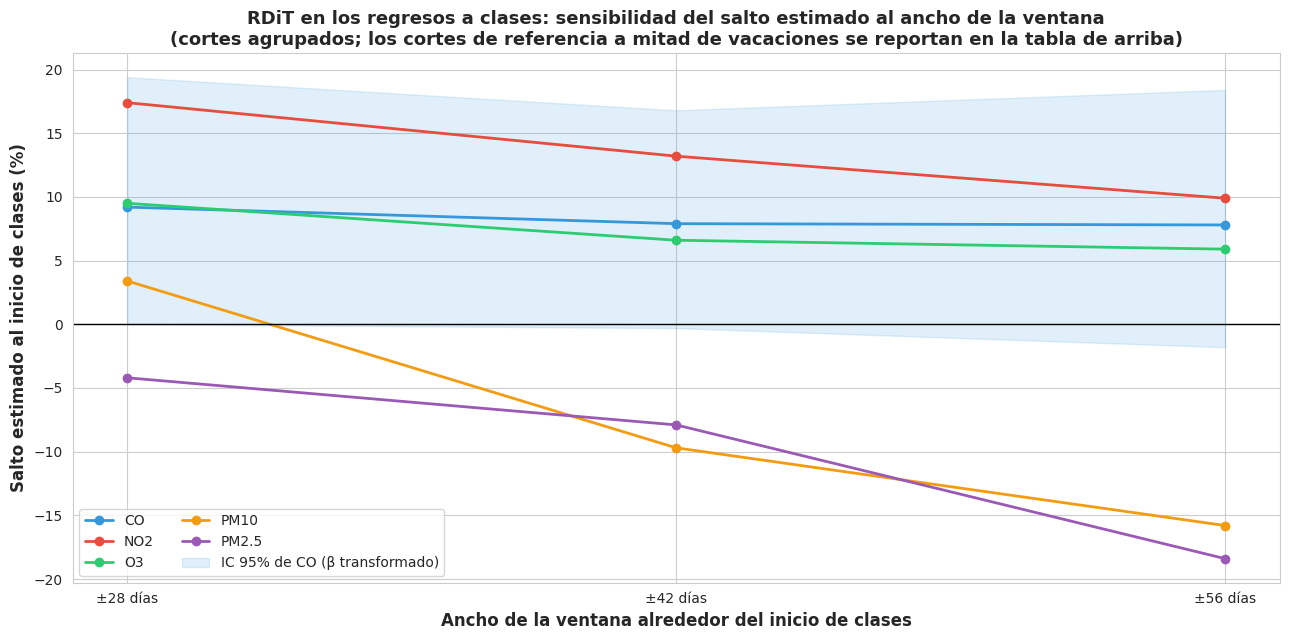

Guardado gráfico en: ../data_processed/graficos_metodos/03_rdit_sensibilidad_ventana.png


In [6]:
fig, ax = plt.subplots(figsize=(13, 6.5))

anchos = [28, 42, 56]
for c in contaminantes:
    valores = [resultados_rdit['clases'][f'±{a}d'][c]['pct'] for a in anchos]
    ax.plot(anchos, valores, marker='o', linewidth=2, color=colores_contaminantes[c], label=c)

# Banda de IC para CO (el contaminante del diseño de franjas)
ci_lo = [resultados_rdit['clases'][f'±{a}d']['CO']['ci_lo_pct'] for a in anchos]
ci_hi = [resultados_rdit['clases'][f'±{a}d']['CO']['ci_hi_pct'] for a in anchos]
ax.fill_between(anchos, ci_lo, ci_hi, color='#3498db', alpha=0.15, label='IC 95% de CO (β transformado)')

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(anchos)
ax.set_xticklabels(['±28 días', '±42 días', '±56 días'])
ax.set_xlabel('Ancho de la ventana alrededor del inicio de clases', fontsize=12, fontweight='bold')
ax.set_ylabel('Salto estimado al inicio de clases (%)', fontsize=12, fontweight='bold')
ax.set_title('RDiT en los regresos a clases: sensibilidad del salto estimado al ancho de la ventana\n(cortes agrupados; los cortes de referencia a mitad de vacaciones se reportan en la tabla de arriba)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.savefig(graficos_dir / '03_rdit_sensibilidad_ventana.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {graficos_dir / '03_rdit_sensibilidad_ventana.png'}")

## 6. GEE AR(1) por estación (método de reserva)

### La ecuación del GEE

El mismo modelo en media que el ITS, estimado por ecuaciones de estimación
generalizadas con correlación de trabajo AR(1) dentro de cada estación:
$\operatorname{corr}(u_t, u_{t-s}) = \rho^{s}$. La varianza sandwich se agrupa por
estación — y solo hay 6 grupos, de ahí la cautela con la que se reporta.

In [7]:
X_gee = pd.concat([panel[['clase']].astype(float), panel[columnas_fourier],
                   (panel['t'] / 365.25).rename('tendencia'),
                   pd.get_dummies(panel['dow'], prefix='dow', drop_first=True).astype(float)], axis=1)
X_gee = sm.add_constant(X_gee)

resultados_gee = {}
print("=" * 70)
print("GEE AR(1) POR ESTACIÓN (solo 6 clusters: cautela, método de reserva)")
print("=" * 70)
for c in contaminantes:
    try:
        modelo = GEE(panel[f'l_{c}'], X_gee, groups=panel['estacion'], time=panel['t'].values,
                     cov_struct=Autoregressive(grid=True), family=sm.families.Gaussian()).fit(maxiter=100)
        beta = modelo.params['clase']
        resultados_gee[c] = {'pct': round((np.exp(beta) - 1) * 100, 2),
                             'p': round(float(modelo.pvalues['clase']), 6),
                             'ar1': round(float(getattr(modelo.cov_struct, 'dep_params', np.nan)), 3)}
        print(f"  {c}: {resultados_gee[c]['pct']:+.1f}% | p = {resultados_gee[c]['p']} | AR1 = {resultados_gee[c]['ar1']}")
    except Exception as e:
        resultados_gee[c] = {'error': str(e)[:120]}
print("=> Con 6 clusters el sandwich produce errores estándar engañosamente chicos")
print("   (Cameron & Miller 2015); estos números se documentan pero no se interpretan.")

GEE AR(1) POR ESTACIÓN (solo 6 clusters: cautela, método de reserva)
  CO: +3.6% | p = 0.0 | AR1 = 0.783
  NO2: +6.1% | p = 0.0 | AR1 = 0.548
  O3: -4.9% | p = 0.01321 | AR1 = 0.394
  PM10: -2.5% | p = 0.013755 | AR1 = 0.465
  PM2.5: -4.4% | p = 0.011618 | AR1 = 0.435
=> Con 6 clusters el sandwich produce errores estándar engañosamente chicos
   (Cameron & Miller 2015); estos números se documentan pero no se interpretan.


In [8]:
with open(resultados_dir / 'its_rdit_gee.json', 'w') as f:
    json.dump({'ITS_estado': resultados_its, 'saltos_por_corte': saltos_por_corte,
               'RDiT': resultados_rdit, 'GEE': resultados_gee,
               'cortes_clase': cortes_clase, 'cortes_placebo': cortes_placebo},
              f, indent=2, ensure_ascii=False)
print(f"Guardado en: {resultados_dir / 'its_rdit_gee.json'}")

print('\nFINALIZADO')

Guardado en: ../data_processed/resultados_metodos/its_rdit_gee.json

FINALIZADO
